# 🤖 AI Job Market Impact — Exploratory Data Analysis

## Overview
This project explores how Artificial Intelligence is impacting the global job market.
Using a dataset of 30,000 job records, we analyze automation risk, salary trends,
job growth, and AI adoption across industries and locations.

## Dataset
- **Source:** Kaggle
- **Rows:** 30,000
- **Columns:** 13
- **Target Column:** AI Impact Level (Low / Moderate / High)

## Tools Used
- Python, Pandas, NumPy
- Matplotlib, Seaborn
- SciPy (Chi-square, ANOVA)

In [2]:
# Step 1 - Import all required libraries

import numpy as np                        # numerical operations
import pandas as pd                       # data manipulation
import matplotlib.pyplot as plt           # plotting
import seaborn as sns                     # advanced visualization
from scipy.stats import chi2_contingency  # chi-square test
from scipy import stats                   # ANOVA test

## Step 2 — Load Data
Loading the dataset into a Pandas DataFrame for analysis.

In [3]:
# Step 2 - Load the dataset
df = pd.read_csv('ai_job_trends_dataset.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")  # rows and columns

Dataset loaded successfully!
Shape: (30000, 13)


## Step 3 — First Look
Getting a quick overview of the dataset — structure, data types, 
missing values and basic statistics.

In [4]:
# Step 3 - First Look at the dataset

print("First 5 rows:")
df.head()

First 5 rows:


,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57


In [5]:
# Shape of the dataset
print("Shape:", df.shape)

# Column names
print("\nColumn Names:", df.columns.tolist())

# Data types of each column
print("\nData Types:")
print(df.dtypes)

Shape: (30000, 13)

Column Names: ['Job Title', 'Industry', 'Job Status', 'AI Impact Level', 'Median Salary (USD)', 'Required Education', 'Experience Required (Years)', 'Job Openings (2024)', 'Projected Openings (2030)', 'Remote Work Ratio (%)', 'Automation Risk (%)', 'Location', 'Gender Diversity (%)']

Data Types:
Job Title                       object
Industry                        object
Job Status                      object
AI Impact Level                 object
Median Salary (USD)            float64
Required Education              object
Experience Required (Years)      int64
Job Openings (2024)              int64
Projected Openings (2030)        int64
Remote Work Ratio (%)          float64
Automation Risk (%)            float64
Location                        object
Gender Diversity (%)           float64
dtype: object


In [6]:
# Basic statistics of numerical columns
print("Basic Statistics:")
df.describe()

Basic Statistics:


,Median Salary (USD),Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Gender Diversity (%)
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,90119.965639,10.051433,5039.640833,5074.218100,49.836431,50.154229,49.979660
std,34412.013953,6.060678,2861.009654,2866.550722,28.966688,28.754889,17.274665
min,30001.860000,0.000000,100.000000,100.000000,0.000000,0.000000,20.000000
25%,60500.702500,5.000000,2570.000000,2586.750000,24.570000,25.400000,35.070000
50%,90274.115000,10.000000,5034.000000,5106.500000,49.570000,50.020000,49.885000
75%,119454.710000,15.000000,7527.000000,7573.000000,75.100000,75.030000,64.910000
max,149998.500000,20.000000,10000.000000,10000.000000,100.000000,99.990000,80.000000


In [7]:
# Check missing values in each column
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Job Title                      0
Industry                       0
Job Status                     0
AI Impact Level                0
Median Salary (USD)            0
Required Education             0
Experience Required (Years)    0
Job Openings (2024)            0
Projected Openings (2030)      0
Remote Work Ratio (%)          0
Automation Risk (%)            0
Location                       0
Gender Diversity (%)           0
dtype: int64


## Step 4 & 5 — Drop Columns & Handle Missing Values
✅ No unnecessary columns found — all 13 columns are relevant.
✅ No missing values found — dataset is clean and ready for analysis!

In [8]:
# Check unique values in each categorical column
print("Job Title unique values:", df['Job Title'].nunique())
print("Industry unique values:", df['Industry'].nunique())
print("Job Status unique values:", df['Job Status'].nunique())
print("AI Impact Level unique values:", df['AI Impact Level'].nunique())
print("Required Education unique values:", df['Required Education'].nunique())
print("Location unique values:", df['Location'].nunique())

Job Title unique values: 639
Industry unique values: 8
Job Status unique values: 2
AI Impact Level unique values: 3
Required Education unique values: 5
Location unique values: 8


In [9]:
# Check unique values in each categorical column
print("Job Status:", df['Job Status'].unique())
print("AI Impact Level:", df['AI Impact Level'].unique())
print("Required Education:", df['Required Education'].unique())
print("Location:", df['Location'].unique())
print("Industry:", df['Industry'].unique())

Job Status: ['Increasing' 'Decreasing']
AI Impact Level: ['Moderate' 'Low' 'High']
Required Education: ['Master’s Degree' 'Bachelor’s Degree' 'Associate Degree' 'High School'
 'PhD']
Location: ['UK' 'USA' 'Canada' 'Australia' 'Germany' 'China' 'India' 'Brazil']
Industry: ['IT' 'Manufacturing' 'Finance' 'Healthcare' 'Education' 'Entertainment'
 'Retail' 'Transportation']


## Step 6 — Encoding
Encoding will be done at the Multivariate Analysis stage 
for correlation heatmap. Not required for Univariate and 
Bivariate Analysis.

## Step 7 — Univariate Analysis
Analyzing each column individually to understand its distribution.

- Categorical columns → value_counts()
- Numerical columns → histogram + boxplot

### 7.1 — Categorical Columns

In [10]:
# Univariate Analysis - AI Impact Level (Target Column)
print("AI Impact Level Distribution:")
print(df['AI Impact Level'].value_counts())
print("\nPercentage:")
print(df['AI Impact Level'].value_counts(normalize=True)*100)

AI Impact Level Distribution:
AI Impact Level
Moderate    10042
High        10005
Low          9953
Name: count, dtype: int64

Percentage:
AI Impact Level
Moderate    33.473333
High        33.350000
Low         33.176667
Name: proportion, dtype: float64


In [11]:
import os
os.makedirs('images', exist_ok=True)

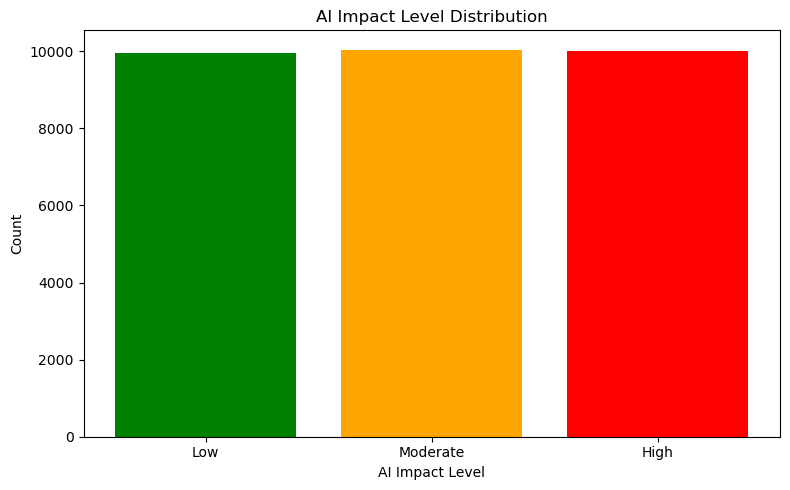

In [12]:
# Plot - AI Impact Level Distribution
plt.figure(figsize=(8,5))
order = ['Low', 'Moderate', 'High']
counts = df['AI Impact Level'].value_counts()
plt.bar(order, 
        [counts['Low'], counts['Moderate'], counts['High']],
        color=['green','orange','red'])
plt.title('AI Impact Level Distribution')
plt.xlabel('AI Impact Level')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('images/ai_impact_distribution.png')
plt.show()

### 📌 Finding 1:
The target column **AI Impact Level** is perfectly balanced with approximately 
33% records in each category (Low, Moderate, High). 
This ensures fair and unbiased analysis!

In [13]:
# Univariate Analysis - Industry
print("Industry Distribution:")
print(df['Industry'].value_counts())
print("\nPercentage:")
print(df['Industry'].value_counts(normalize=True)*100)

Industry Distribution:
Industry
Entertainment     3895
Manufacturing     3855
Healthcare        3771
Finance           3721
Education         3714
Retail            3702
IT                3681
Transportation    3661
Name: count, dtype: int64

Percentage:
Industry
Entertainment     12.983333
Manufacturing     12.850000
Healthcare        12.570000
Finance           12.403333
Education         12.380000
Retail            12.340000
IT                12.270000
Transportation    12.203333
Name: proportion, dtype: float64


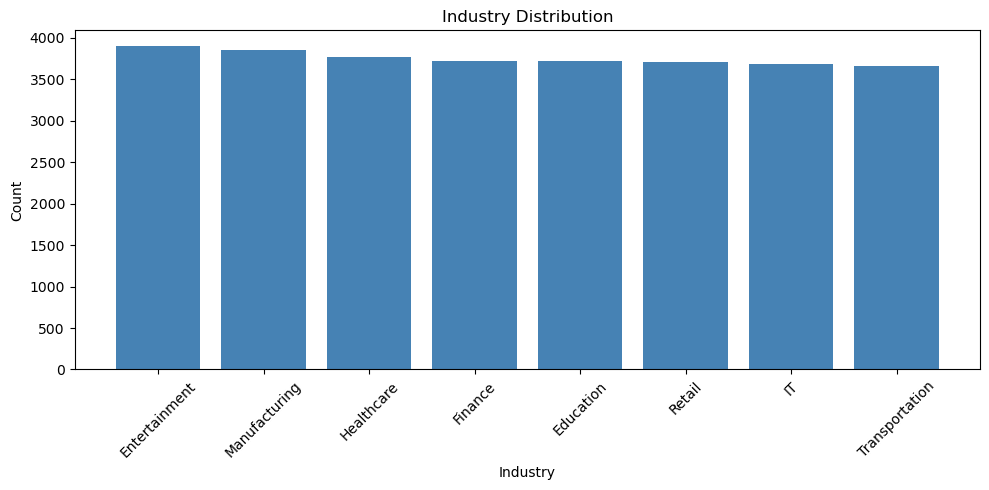

In [14]:
# Plot - Industry Distribution
plt.figure(figsize=(10,5))
plt.bar(df['Industry'].value_counts().index,
        df['Industry'].value_counts().values,
        color='steelblue')
plt.title('Industry Distribution')
plt.xlabel('Industry')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/industry_distribution.png')
plt.show()

### 📌 Finding 2:
All 8 industries are almost equally represented (~12-13% each).
**Entertainment** has the most jobs (3895) and **Transportation** 
has the least (3661). The balanced distribution ensures unbiased 
analysis across all industries!

In [15]:
# Univariate Analysis - Job Status
print("Job Status Distribution:")
print(df['Job Status'].value_counts())
print("\nPercentage:")
print(df['Job Status'].value_counts(normalize=True)*100)

Job Status Distribution:
Job Status
Increasing    15136
Decreasing    14864
Name: count, dtype: int64

Percentage:
Job Status
Increasing    50.453333
Decreasing    49.546667
Name: proportion, dtype: float64


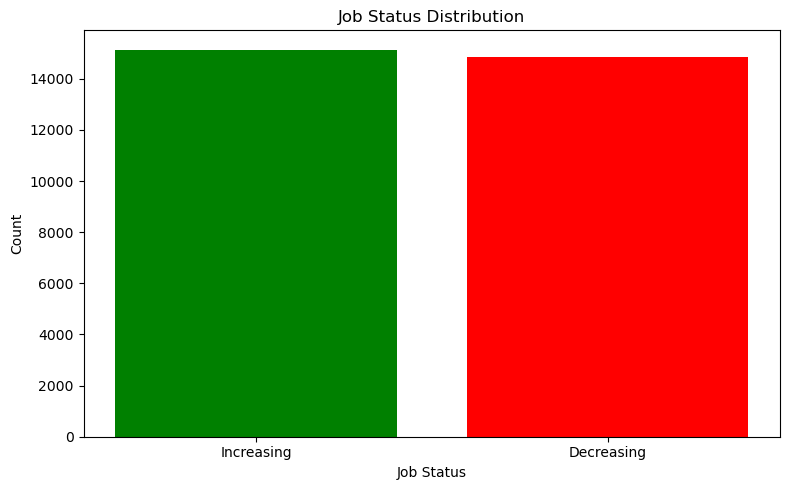

In [16]:
# Plot - Job Status Distribution
plt.figure(figsize=(8,5))
plt.bar(df['Job Status'].value_counts().index,
        df['Job Status'].value_counts().values,
        color=['green','red'])
plt.title('Job Status Distribution')
plt.xlabel('Job Status')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('images/job_status_distribution.png')
plt.show()

### 📌 Finding 3:
Job Status is almost perfectly balanced — **50.4% Increasing** and 
**49.5% Decreasing**. This suggests AI is simultaneously creating 
new jobs while replacing traditional ones in equal measure!

In [17]:
print("Required Education:")
print(df["Required Education"].value_counts())
print("\n percentage")
print(df["Required Education"].value_counts(normalize=True)*100)

Required Education:
Required Education
Bachelor’s Degree    6146
Master’s Degree      6097
Associate Degree     6003
High School          5900
PhD                  5854
Name: count, dtype: int64

 percentage
Required Education
Bachelor’s Degree    20.486667
Master’s Degree      20.323333
Associate Degree     20.010000
High School          19.666667
PhD                  19.513333
Name: proportion, dtype: float64


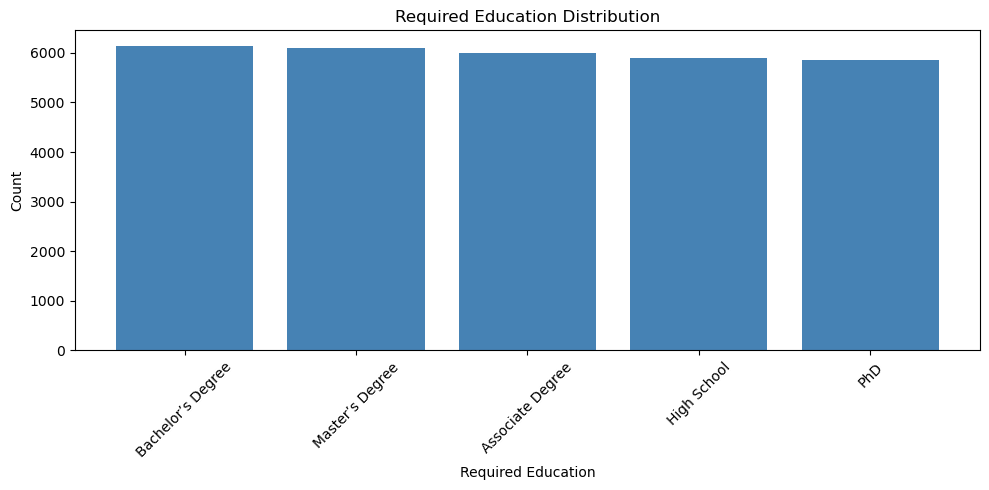

In [18]:
# Plot - Industry Distribution
plt.figure(figsize=(10,5))
plt.bar(df['Required Education'].value_counts().index,
        df['Required Education'].value_counts().values,
        color='steelblue')
plt.title('Required Education Distribution')
plt.xlabel('Required Education')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/required_education_distribution.png')
plt.show()

### 📌 Finding 4:
Required Education is perfectly balanced across all 5 levels (~20% each).
**Bachelor's Degree** is most common (20.48%) while **PhD** is least common (19.51%).
Interestingly, AI impacts jobs across ALL education levels equally — 
higher education does not guarantee protection from automation!

In [19]:
print("Location:")
print(df["Location"].value_counts())
print("\n percentage")
print(df["Location"].value_counts(normalize=True)*100)

Location:
Location
Australia    3802
UK           3784
Canada       3775
China        3763
Germany      3741
Brazil       3728
USA          3713
India        3694
Name: count, dtype: int64

 percentage
Location
Australia    12.673333
UK           12.613333
Canada       12.583333
China        12.543333
Germany      12.470000
Brazil       12.426667
USA          12.376667
India        12.313333
Name: proportion, dtype: float64


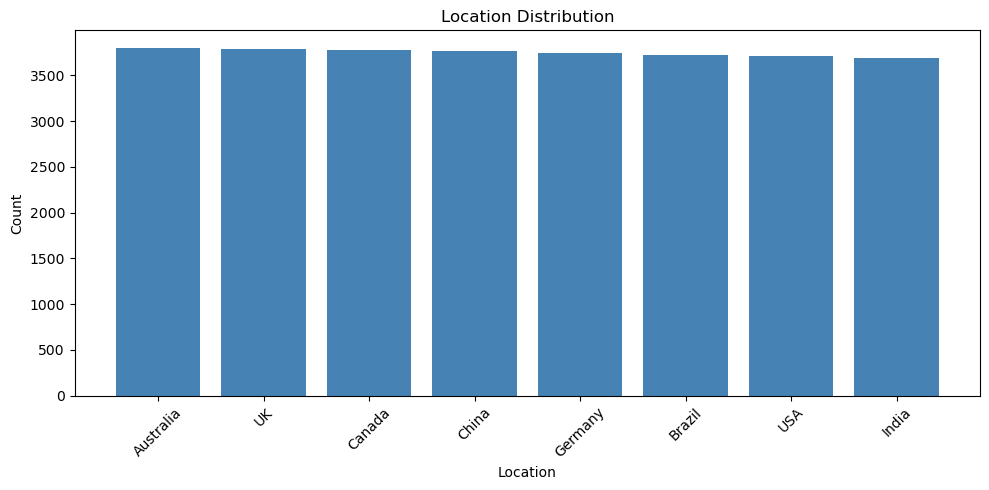

In [20]:
# Plot - Industry Distribution
plt.figure(figsize=(10,5))
plt.bar(df['Location'].value_counts().index,
        df['Location'].value_counts().values,
        color='steelblue')
plt.title('Location Distribution')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/required_Location_distribution.png')
plt.show()

### 📌 Finding 5:
All 8 countries are almost equally represented (~12.5% each).
**Australia** has the most records (3802) and **India** the least (3694).
This confirms that AI's impact on jobs is a **global phenomenon** — 
affecting every country equally, from developing nations like India 
and Brazil to developed ones like USA and Australia!

### 7.2 — Numerical Columns

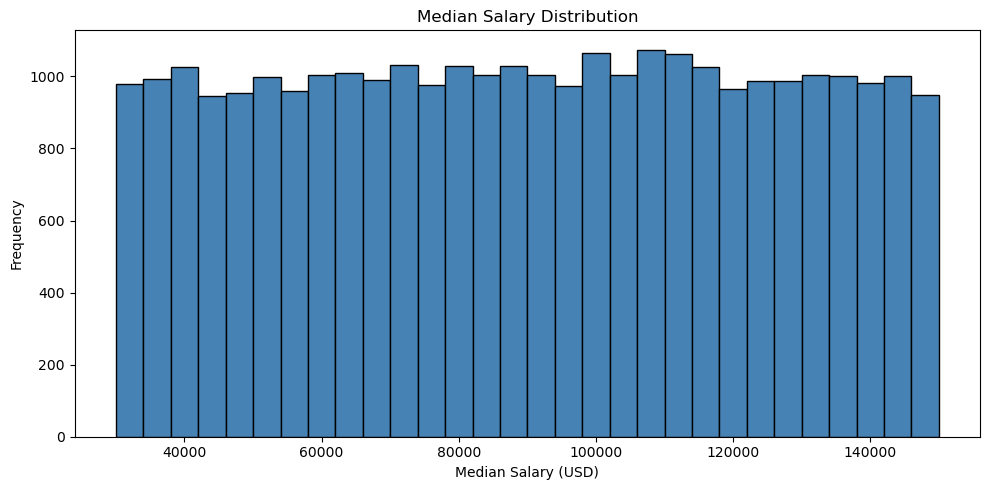

In [21]:
# Univariate Analysis - Median Salary (USD)
# Histogram - to check distribution and skewness
plt.figure(figsize=(10,5))
plt.hist(df['Median Salary (USD)'], bins=30, color='steelblue', edgecolor='black')
plt.title('Median Salary Distribution')
plt.xlabel('Median Salary (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/salary_distribution.png')
plt.show()

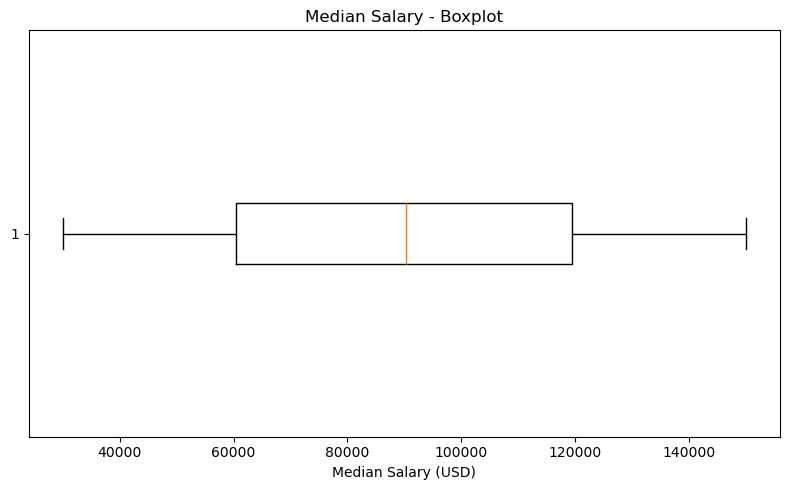

In [22]:
# Boxplot - to check outliers in Median Salary
plt.figure(figsize=(8,5))
plt.boxplot(df['Median Salary (USD)'], vert=False)
plt.title('Median Salary - Boxplot')
plt.xlabel('Median Salary (USD)')
plt.tight_layout()
plt.savefig('images/salary_boxplot.png')
plt.show()

### 📌 Finding 6:
**Median Salary** is normally distributed with no outliers.
- Most jobs pay around **$90,000**
- Salary ranges from **$30,000 to $150,000**
- No extreme high or low salaries exist
- Mean ≈ Median → confirms normal distribution!

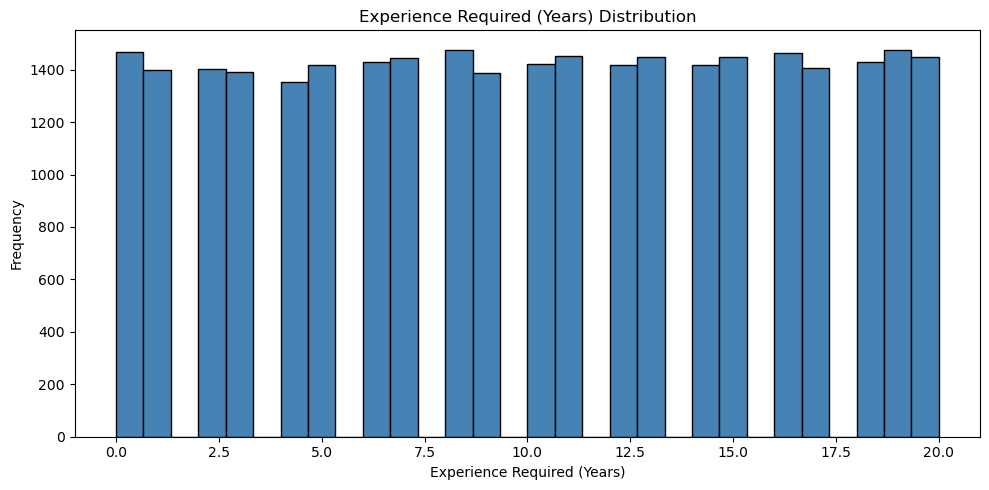

In [23]:
# Univariate Analysis - Experience Required (Years)
# Histogram - to check distribution and skewness
plt.figure(figsize=(10,5))
plt.hist(df['Experience Required (Years)'], bins=30, color='steelblue', edgecolor='black')
plt.title('Experience Required (Years) Distribution')
plt.xlabel('Experience Required (Years)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/experience_distribution.png')
plt.show()

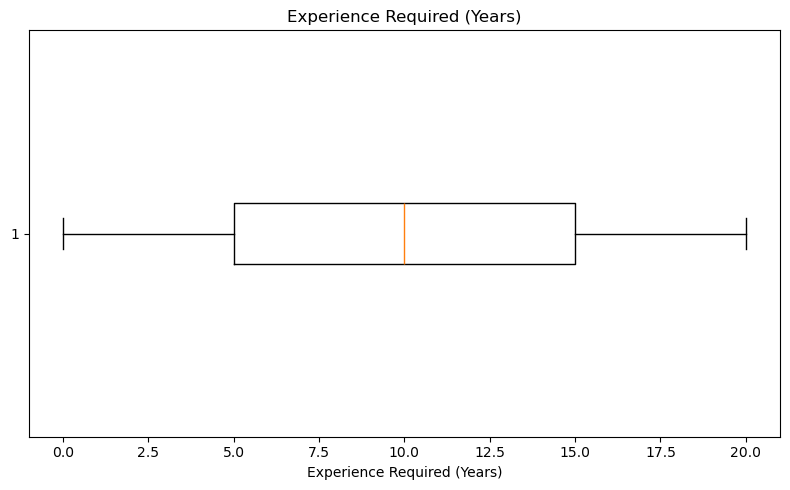

In [24]:
# Boxplot - to check outliers in Experience Required (Years)
plt.figure(figsize=(8,5))
plt.boxplot(df['Experience Required (Years)'], vert=False)
plt.title('Experience Required (Years)')
plt.xlabel('Experience Required (Years)')
plt.tight_layout()
plt.savefig('images/experience_boxplot.png')
plt.show()

### 📌 Finding 7:
**Experience Required** shows a uniform distribution — 
all experience levels (0-20 years) are equally represented.
- No outliers present
- Median experience = **10 years**
- AI impacts jobs across ALL experience levels equally —
  from freshers (0 years) to highly experienced (20 years)!

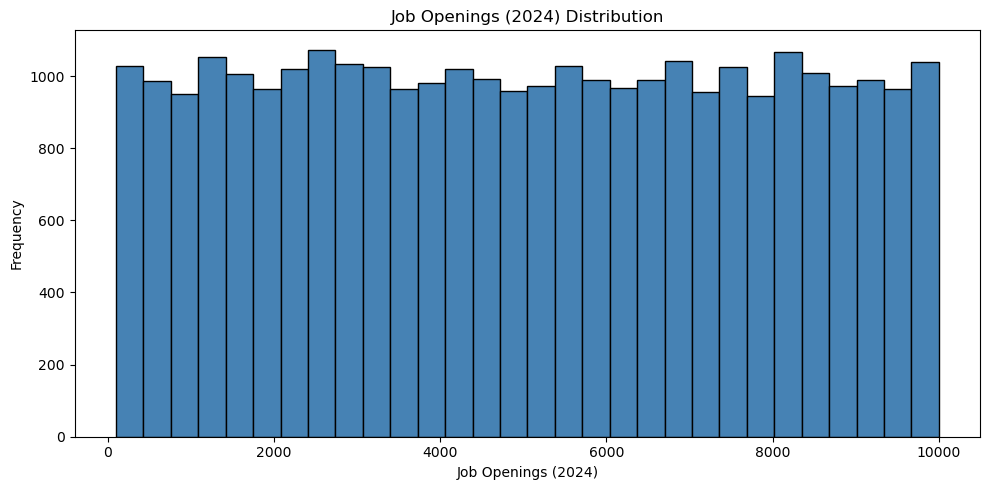

In [25]:
# Univariate Analysis - Job Openings (2024)
# Histogram - to check distribution and skewness
plt.figure(figsize=(10,5))
plt.hist(df['Job Openings (2024)'], bins=30, color='steelblue', edgecolor='black')
plt.title('Job Openings (2024) Distribution')
plt.xlabel('Job Openings (2024)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/job_openings_distribution.png')
plt.show()

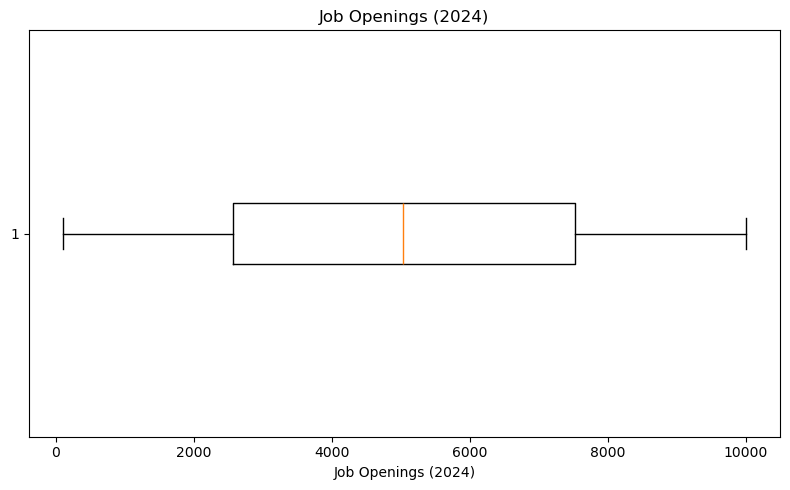

In [26]:
# Boxplot - to check outliers in Job Openings (2024)
plt.figure(figsize=(8,5))
plt.boxplot(df['Job Openings (2024)'], vert=False)
plt.title('Job Openings (2024)')
plt.xlabel('Job Openings (2024)')
plt.tight_layout()
plt.savefig('images/job_openings_boxplot.png')
plt.show()

### 📌 Finding 8:
**Job Openings (2024)** shows a uniform distribution.
- Job openings range from **100 to 10,000**
- No outliers present
- Median = **~5,000 openings**
- All job opening ranges are equally common!

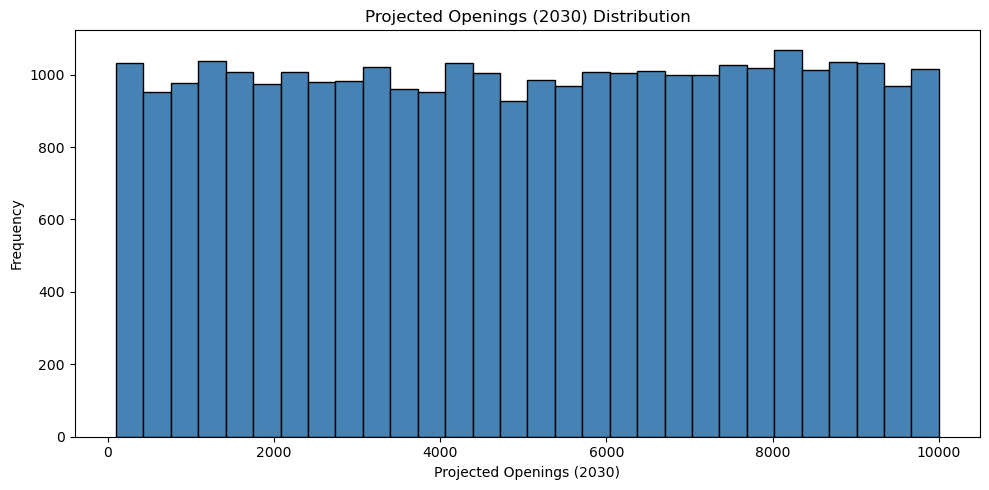

In [27]:
# Univariate Analysis - Projected Openings (2030)
# Histogram - to check distribution and skewness
plt.figure(figsize=(10,5))
plt.hist(df['Projected Openings (2030)'], bins=30, color='steelblue', edgecolor='black')
plt.title('Projected Openings (2030) Distribution')
plt.xlabel('Projected Openings (2030)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/projected_openings_distribution.png')
plt.show()

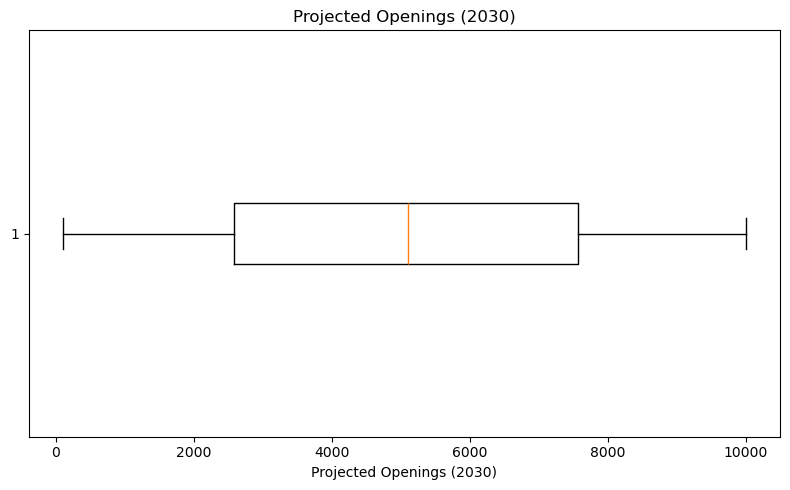

In [28]:
# Boxplot - to check outliers in Projected Openings (2030)
plt.figure(figsize=(8,5))
plt.boxplot(df['Projected Openings (2030)'], vert=False)
plt.title('Projected Openings (2030)')
plt.xlabel('Projected Openings (2030)')
plt.tight_layout()
plt.savefig('images/projected_openings_boxplot.png')
plt.show()

### 📌 Finding 9:
**Projected Openings (2030)** shows same uniform distribution as Job Openings (2024).
- Range and median remain similar (~5,000)
- No outliers present
- **Interesting observation:** In reality, AI-related job openings 
  should grow 2x or 3x by 2030 — but this synthetic dataset 
  shows steady growth, which may not reflect real world trends!

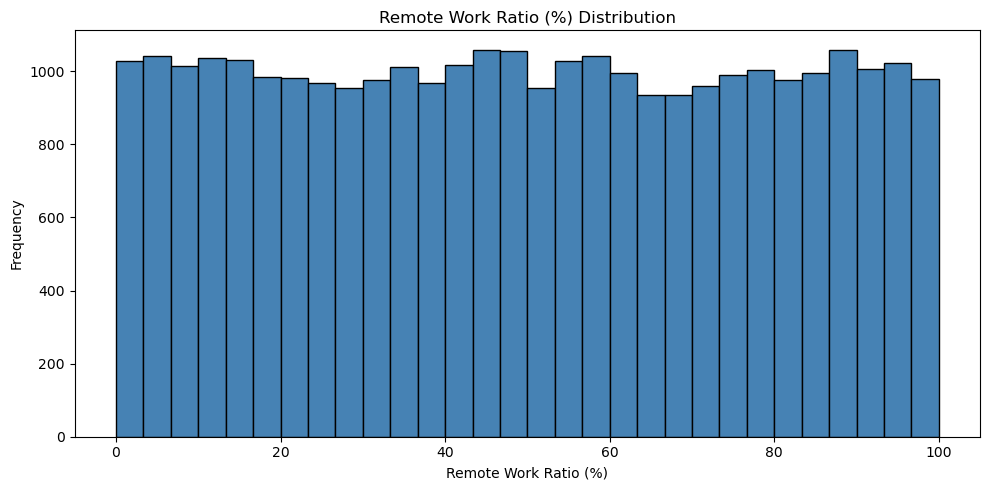

In [29]:
# Univariate Analysis - Remote Work Ratio (%)'
# Histogram - to check distribution and skewness
plt.figure(figsize=(10,5))
plt.hist(df['Remote Work Ratio (%)'], bins=30, color='steelblue', edgecolor='black')
plt.title('Remote Work Ratio (%) Distribution')
plt.xlabel('Remote Work Ratio (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/remote_work_distribution.png')
plt.show()

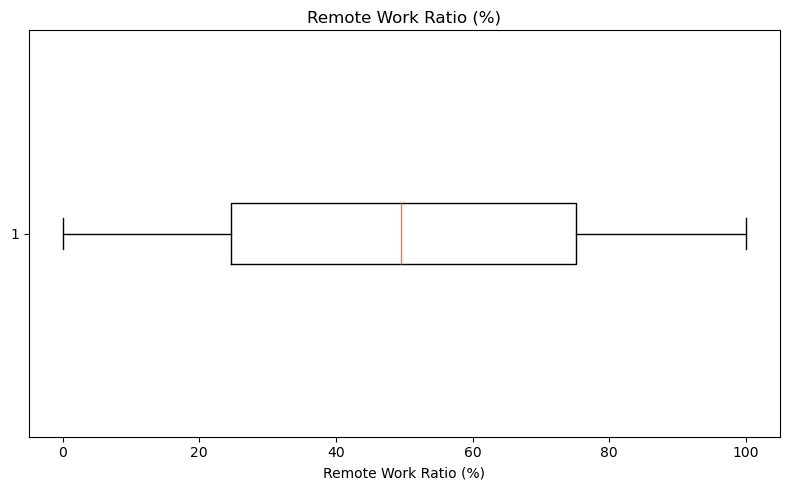

In [30]:
# Boxplot - to check outliers in Remote Work Ratio (%)
plt.figure(figsize=(8,5))
plt.boxplot(df['Remote Work Ratio (%)'], vert=False)
plt.title('Remote Work Ratio (%)')
plt.xlabel('Remote Work Ratio (%)')
plt.tight_layout()
plt.savefig('images/remote_work_boxplot.png')
plt.show()

### 📌 Finding 10:
**Remote Work Ratio** shows uniform distribution.
- Range: **0% to 100%** remote work
- Median = **~50%** remote work ratio
- No outliers present
- AI impacts both fully remote and fully on-site jobs equally!

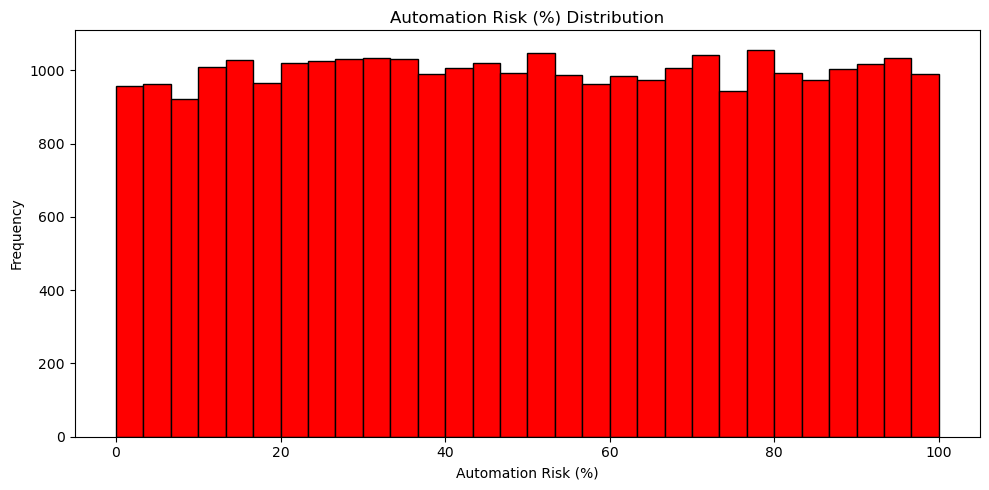

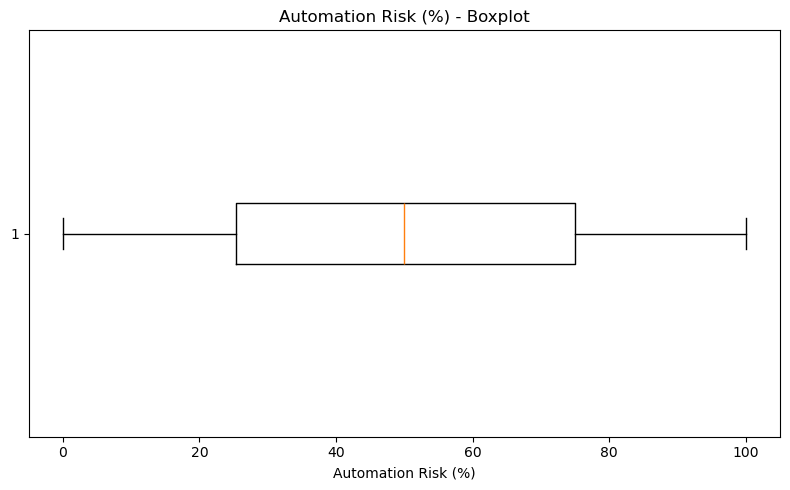

In [31]:
# Univariate Analysis - Automation Risk (%)
# Histogram
plt.figure(figsize=(10,5))
plt.hist(df['Automation Risk (%)'], bins=30, color='red', edgecolor='black')
plt.title('Automation Risk (%) Distribution')
plt.xlabel('Automation Risk (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/automation_risk_distribution.png')
plt.show()

# Boxplot
plt.figure(figsize=(8,5))
plt.boxplot(df['Automation Risk (%)'], vert=False)
plt.title('Automation Risk (%) - Boxplot')
plt.xlabel('Automation Risk (%)')
plt.tight_layout()
plt.savefig('images/automation_risk_boxplot.png')
plt.show()

### 📌 Finding 11:
**Automation Risk (%)** shows a uniform distribution.
- Range: **0% to 99.99%** automation risk
- Median = **~50%** automation risk
- No outliers present
- Every level of automation risk is equally common —
  some jobs are nearly 100% at risk while others are barely affected!

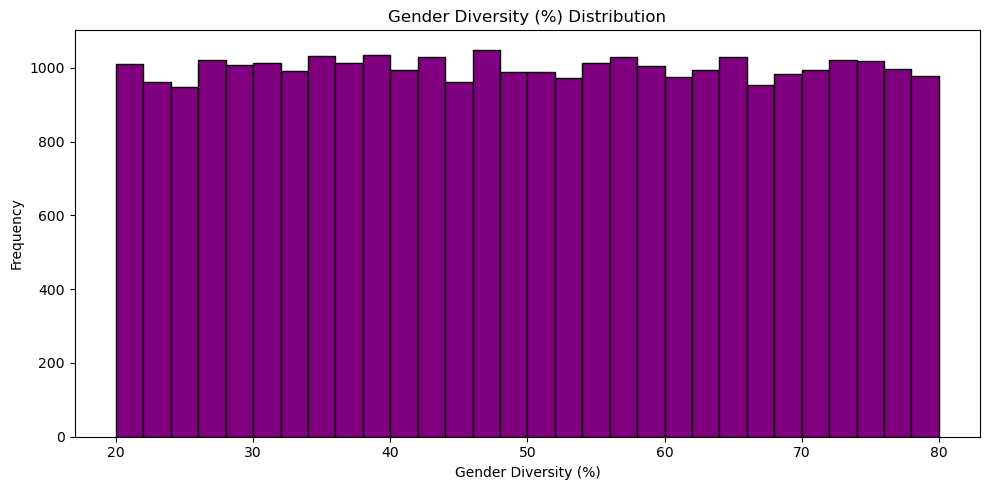

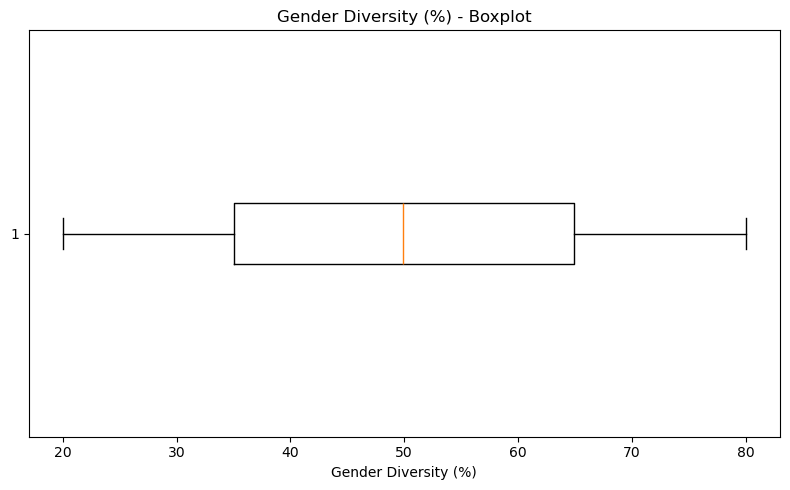

In [32]:
# Univariate Analysis - Gender Diversity (%)
# Histogram
plt.figure(figsize=(10,5))
plt.hist(df['Gender Diversity (%)'], bins=30, color='purple', edgecolor='black')
plt.title('Gender Diversity (%) Distribution')
plt.xlabel('Gender Diversity (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/gender_diversity_distribution.png')
plt.show()

# Boxplot
plt.figure(figsize=(8,5))
plt.boxplot(df['Gender Diversity (%)'], vert=False)
plt.title('Gender Diversity (%) - Boxplot')
plt.xlabel('Gender Diversity (%)')
plt.tight_layout()
plt.savefig('images/gender_diversity_boxplot.png')
plt.show()

### 📌 Finding 12:
**Gender Diversity (%)** shows a uniform distribution.
- Range: **20% to 80%** gender diversity
- Median = **~50%** gender diversity
- No outliers present
- Gender diversity is equally spread across all job roles —
  no single gender dominates any particular field!

## Step 8 — Bivariate Analysis
Analyzing relationship between each column and target column (AI Impact Level).
- Categorical vs Target → Chi-square test
- Numerical vs Target → ANOVA test
- p < 0.05 → Dependent (significant)
- p > 0.05 → Independent (not significant)

### 8.1 — Categorical vs Target (Chi-square Test)

In [33]:
# Chi-square test - Industry vs AI Impact Level
ct = pd.crosstab(df['Industry'], df['AI Impact Level'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Industry vs AI Impact Level")
print(f"Chi-square value: {chi2:.4f}")
print(f"P-value: {p:.4f}")
if p < 0.05:
    print("Result: DEPENDENT (significant) ✅")
else:
    print("Result: INDEPENDENT (not significant) ❌")

Industry vs AI Impact Level
Chi-square value: 12.6068
P-value: 0.5577
Result: INDEPENDENT (not significant) ❌


### 📌 Finding 13:
**Industry vs AI Impact Level** → INDEPENDENT (p = 0.5577)
AI impact is equal across ALL industries — IT, Healthcare, 
Finance, Entertainment etc. No single industry is more 
vulnerable to AI than others!

In [34]:
# Chi-square test - Job Status vs AI Impact Level
ct = pd.crosstab(df['Job Status'], df['AI Impact Level'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Job Status vs AI Impact Level")
print(f"Chi-square value: {chi2:.4f}")
print(f"P-value: {p:.4f}")
if p < 0.05:
    print("Result: DEPENDENT (significant) ✅")
else:
    print("Result: INDEPENDENT (not significant) ❌")

Job Status vs AI Impact Level
Chi-square value: 1.5638
P-value: 0.4575
Result: INDEPENDENT (not significant) ❌


### 📌 Finding 14:
**Job Status vs AI Impact Level** → INDEPENDENT (p = 0.4575)
Whether a job is Increasing or Decreasing does NOT 
determine its AI Impact Level. AI affects both growing 
and declining jobs equally!

In [35]:
# Chi-square test - Required Education vs AI Impact Level
ct = pd.crosstab(df['Required Education'], df['AI Impact Level'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Required Education vs AI Impact Level")
print(f"Chi-square value: {chi2:.4f}")
print(f"P-value: {p:.4f}")
if p < 0.05:
    print("Result: DEPENDENT (significant) ✅")
else:
    print("Result: INDEPENDENT (not significant) ❌")

Required Education vs AI Impact Level
Chi-square value: 6.1465
P-value: 0.6308
Result: INDEPENDENT (not significant) ❌


### 📌 Finding 15:
**Required Education vs AI Impact Level** → INDEPENDENT (p = 0.6308)
Education level does NOT determine AI Impact Level.
A PhD holder is equally affected by AI as a High School 
graduate — education alone cannot protect you from automation!

In [36]:
# Chi-square test - Location vs AI Impact Level
ct = pd.crosstab(df['Location'], df['AI Impact Level'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Location vs AI Impact Level")
print(f"Chi-square value: {chi2:.4f}")
print(f"P-value: {p:.4f}")
if p < 0.05:
    print("Result: DEPENDENT (significant) ✅")
else:
    print("Result: INDEPENDENT (not significant) ❌")

Location vs AI Impact Level
Chi-square value: 16.3100
P-value: 0.2948
Result: INDEPENDENT (not significant) ❌


### 📌 Finding 16:
**Location vs AI Impact Level** → INDEPENDENT (p = 0.2948)
Country/Location does NOT determine AI Impact Level.
AI is a **global phenomenon** — it affects jobs equally 
across all 8 countries in this dataset!

### 8.2 — Numerical vs Target (ANOVA Test)

In [37]:
# ANOVA test - Median Salary vs AI Impact Level
low = df[df['AI Impact Level'] == 'Low']['Median Salary (USD)']
moderate = df[df['AI Impact Level'] == 'Moderate']['Median Salary (USD)']
high = df[df['AI Impact Level'] == 'High']['Median Salary (USD)']

f_stat, p = stats.f_oneway(low, moderate, high)
print("Median Salary vs AI Impact Level")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p:.4f}")
if p < 0.05:
    print("Result: DEPENDENT (significant) ✅")
else:
    print("Result: INDEPENDENT (not significant) ❌")

Median Salary vs AI Impact Level
F-statistic: 0.9264
P-value: 0.3960
Result: INDEPENDENT (not significant) ❌


### 📌 Finding 17:
**Median Salary vs AI Impact Level** → INDEPENDENT (p = 0.3960)
Salary does NOT determine AI Impact Level.
High paying jobs are equally at risk from AI as low paying jobs!
Money cannot protect you from automation!

In [41]:
# ANOVA test - Experience Required vs AI Impact Level
low = df[df['AI Impact Level'] == 'Low']['Experience Required (Years)']
moderate = df[df['AI Impact Level'] == 'Moderate']['Experience Required (Years)']
high = df[df['AI Impact Level'] == 'High']['Experience Required (Years)']

f_stat, p = stats.f_oneway(low, moderate, high)
print("Experience Required vs AI Impact Level")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p:.4f}")
if p < 0.05:
    print("Result: DEPENDENT (significant) ✅")
else:
    print("Result: INDEPENDENT (not significant) ❌")

Experience Required vs AI Impact Level
F-statistic: 0.6495
P-value: 0.5223
Result: INDEPENDENT (not significant) ❌


In [42]:
# ANOVA test - Job Openings (2024) vs AI Impact Level
low = df[df['AI Impact Level'] == 'Low']['Job Openings (2024)']
moderate = df[df['AI Impact Level'] == 'Moderate']['Job Openings (2024)']
high = df[df['AI Impact Level'] == 'High']['Job Openings (2024)']

f_stat, p = stats.f_oneway(low, moderate, high)
print("Job Openings (2024) vs AI Impact Level")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p:.4f}")
if p < 0.05:
    print("Result: DEPENDENT (significant) ✅")
else:
    print("Result: INDEPENDENT (not significant) ❌")

Job Openings (2024) vs AI Impact Level
F-statistic: 0.4446
P-value: 0.6411
Result: INDEPENDENT (not significant) ❌


In [44]:
# ANOVA test - Projected Openings (2030) vs AI Impact Level
low = df[df['AI Impact Level'] == 'Low']['Projected Openings (2030)']
moderate = df[df['AI Impact Level'] == 'Moderate']['Projected Openings (2030)']
high = df[df['AI Impact Level'] == 'High']['Projected Openings (2030)']

f_stat, p = stats.f_oneway(low, moderate, high)
print("Projected Openings (2030) vs AI Impact Level")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p:.4f}")
if p < 0.05:
    print("Result: DEPENDENT (significant) ✅")
else:
    print("Result: INDEPENDENT (not significant) ❌")

Projected Openings (2030) vs AI Impact Level
F-statistic: 0.7788
P-value: 0.4590
Result: INDEPENDENT (not significant) ❌


In [45]:
# ANOVA test - Remote Work Ratio (%) vs AI Impact Level
low = df[df['AI Impact Level'] == 'Low']['Remote Work Ratio (%)']
moderate = df[df['AI Impact Level'] == 'Moderate']['Remote Work Ratio (%)']
high = df[df['AI Impact Level'] == 'High']['Remote Work Ratio (%)']

f_stat, p = stats.f_oneway(low, moderate, high)
print("Remote Work Ratio (%) vs AI Impact Level")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p:.4f}")
if p < 0.05:
    print("Result: DEPENDENT (significant) ✅")
else:
    print("Result: INDEPENDENT (not significant) ❌")

Remote Work Ratio (%) vs AI Impact Level
F-statistic: 1.0648
P-value: 0.3448
Result: INDEPENDENT (not significant) ❌


In [46]:
# ANOVA test - Automation Risk (%) vs AI Impact Level
low = df[df['AI Impact Level'] == 'Low']['Automation Risk (%)']
moderate = df[df['AI Impact Level'] == 'Moderate']['Automation Risk (%)']
high = df[df['AI Impact Level'] == 'High']['Automation Risk (%)']

f_stat, p = stats.f_oneway(low, moderate, high)
print("Automation Risk (%) vs AI Impact Level")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p:.4f}")
if p < 0.05:
    print("Result: DEPENDENT (significant) ✅")
else:
    print("Result: INDEPENDENT (not significant) ❌")

Automation Risk (%) vs AI Impact Level
F-statistic: 2.5557
P-value: 0.0777
Result: INDEPENDENT (not significant) ❌


In [47]:
# ANOVA test - Gender Diversity (%) vs AI Impact Level
low = df[df['AI Impact Level'] == 'Low']['Gender Diversity (%)']
moderate = df[df['AI Impact Level'] == 'Moderate']['Gender Diversity (%)']
high = df[df['AI Impact Level'] == 'High']['Gender Diversity (%)']

f_stat, p = stats.f_oneway(low, moderate, high)
print("Gender Diversity (%) vs AI Impact Level")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p:.4f}")
if p < 0.05:
    print("Result: DEPENDENT (significant) ✅")
else:
    print("Result: INDEPENDENT (not significant) ❌")

Gender Diversity (%) vs AI Impact Level
F-statistic: 0.3326
P-value: 0.7171
Result: INDEPENDENT (not significant) ❌


### 📌 Finding 18 — Key Insight:
**ALL columns are INDEPENDENT of AI Impact Level (p > 0.05)**

Chi-square Tests — All Independent:
- Industry (p = 0.5577), Job Status (p = 0.4575)
- Required Education (p = 0.6308), Location (p = 0.2948)

ANOVA Tests — All Independent:
- Median Salary (p = 0.3960), Experience Required (p = 0.5223)
- Job Openings 2024 (p = 0.6411), Projected Openings 2030 (p = 0.4590)
- Remote Work Ratio (p = 0.3448), Automation Risk (p = 0.0777)
- Gender Diversity (p = 0.7171)

⚠️ Note: This is expected because this is a SYNTHETIC dataset.
In real world data, columns like Automation Risk and Salary 
would likely show significant relationships with AI Impact Level!

## Step 9 — Multivariate Analysis

### 9.1 — Correlation Heatmap
Analyzing relationships between all numerical columns together.

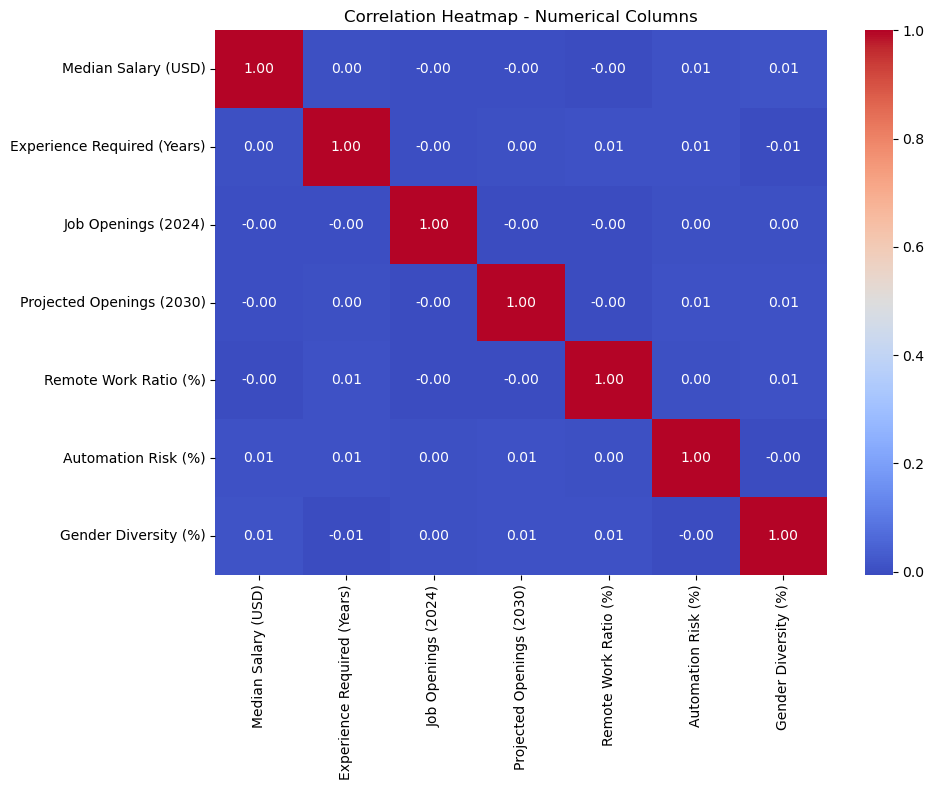

In [51]:
# Step 9.1 - Correlation Heatmap
numerical_cols = ['Median Salary (USD)', 'Experience Required (Years)', 
                  'Job Openings (2024)', 'Projected Openings (2030)',
                  'Remote Work Ratio (%)', 'Automation Risk (%)', 
                  'Gender Diversity (%)']

plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm')
plt.title('Correlation Heatmap - Numerical Columns')
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png')
plt.show()

### 📌 Finding 19:
**Correlation Heatmap** shows near-zero correlation between all numerical columns.
- Diagonal values = 1.00 (self correlation)
- All other values ≈ 0.00 (no relationship)
- No multicollinearity present in the dataset
- ⚠️ Expected result for synthetic data — in real world datasets,
  columns like Job Openings 2024 and Projected Openings 2030 
  would likely be strongly correlated!

### 9.2 — Scatter Plots (FacetGrid)
Visualizing relationships between numerical columns 
grouped by AI Impact Level.

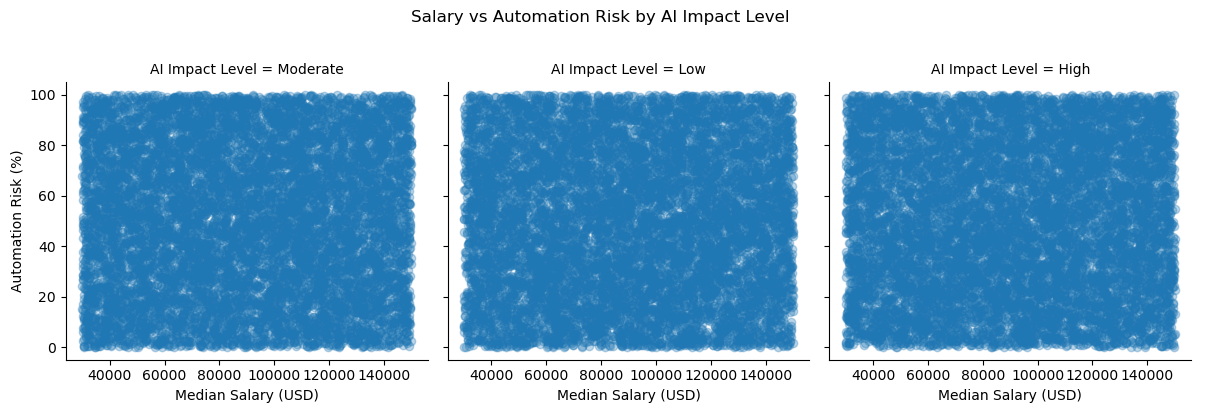

In [52]:
# Scatter Plot - Salary vs Automation Risk grouped by AI Impact Level
g = sns.FacetGrid(df, col='AI Impact Level', height=4)
g.map(plt.scatter, 'Median Salary (USD)', 'Automation Risk (%)', alpha=0.3)
g.add_legend()
g.fig.suptitle('Salary vs Automation Risk by AI Impact Level', y=1.02)
plt.tight_layout()
plt.savefig('images/scatter_salary_vs_automation.png')
plt.show()

### 📌 Finding 20:
**Salary vs Automation Risk** shows no pattern across all 3 AI Impact Levels.
- All 3 panels (Low, Moderate, High) look identical
- No relationship between Salary and Automation Risk
- Confirms synthetic nature of dataset — 
  in real world, high salary jobs would likely have lower automation risk!

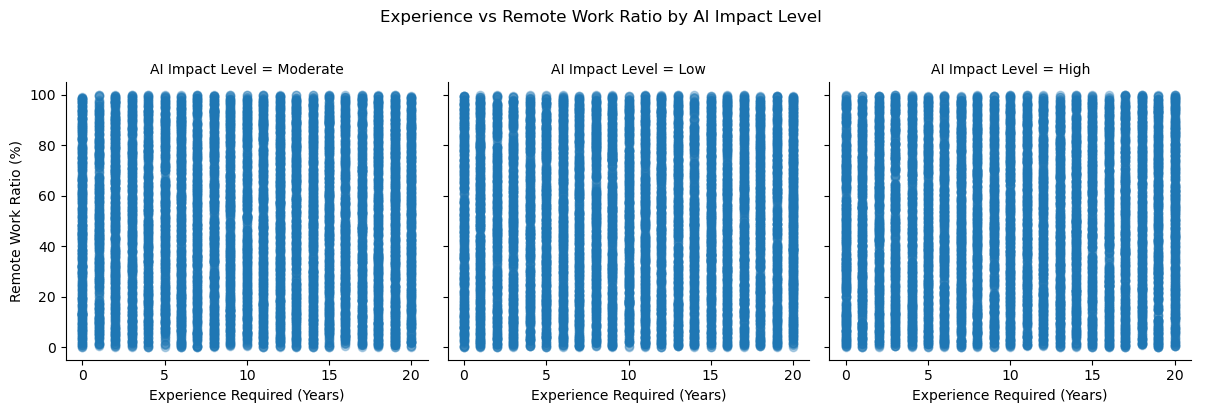

In [53]:
# Scatter Plot - Experience vs Remote Work Ratio grouped by AI Impact Level
g = sns.FacetGrid(df, col='AI Impact Level', height=4)
g.map(plt.scatter, 'Experience Required (Years)', 'Remote Work Ratio (%)', alpha=0.3)
g.add_legend()
g.fig.suptitle('Experience vs Remote Work Ratio by AI Impact Level', y=1.02)
plt.tight_layout()
plt.savefig('images/scatter_experience_vs_remote.png')
plt.show()

### 📌 Finding 21:
**Experience vs Remote Work Ratio** shows no pattern across AI Impact Levels.
- Vertical lines appear because Experience is discrete (0-20 years)
- Every experience level has equal remote work opportunities (0-100%)
- No relationship between experience and remote work ratio
- ⚠️ Again confirms synthetic nature of dataset!